# DATA PROCESSING

### STEP 1: Import required libraries and dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from shapely.geometry import Point

data = pd.read_csv("data_bird/bird_data_ns.csv") # Data credit: iNaturalist.org

data.head()

,observed_on,image_url,latitude,longitude,place_county_name,scientific_name,common_name,taxon_family_name
0,01/01/20,https://static.inaturalist.org/photos/58858125...,45.659409,-61.912969,Antigonish,Spinus tristis,American Goldfinch,Fringillidae
1,01/01/20,https://static.inaturalist.org/photos/58858171...,45.659409,-61.912969,Antigonish,Zenaida macroura,Mourning Dove,Columbidae
2,01/01/20,https://inaturalist-open-data.s3.amazonaws.com...,45.139503,-63.380988,Colchester,Mergus merganser,Common Merganser,Anatidae
3,01/01/20,https://inaturalist-open-data.s3.amazonaws.com...,45.138413,-63.375516,Colchester,Spinus tristis,American Goldfinch,Fringillidae
4,01/01/20,https://inaturalist-open-data.s3.amazonaws.com...,44.710151,-63.693067,Halifax,Junco hyemalis,Dark-eyed Junco,Passerellidae


### STEP 2: After looking at the data, lets manipulate it to certain standards.

In [2]:
data = data[data['scientific_name'] != 'Aves'] # Lets remove the the sightings that say "AVES" aka Birds.

data[['latitude', 'longitude']] = data[['latitude', 'longitude']].round(3) # Rounding to 3 decimals.

data['observed_on'] = pd.to_datetime(data['observed_on'], format='%d/%m/%y')  # Convert to datetime format

bird_data = data.rename(columns = {'observed_on': 'date'})  # Give it a logical name

bird_data.head()

,date,image_url,latitude,longitude,place_county_name,scientific_name,common_name,taxon_family_name
0,2020-01-01,https://static.inaturalist.org/photos/58858125...,45.659,-61.913,Antigonish,Spinus tristis,American Goldfinch,Fringillidae
1,2020-01-01,https://static.inaturalist.org/photos/58858171...,45.659,-61.913,Antigonish,Zenaida macroura,Mourning Dove,Columbidae
2,2020-01-01,https://inaturalist-open-data.s3.amazonaws.com...,45.140,-63.381,Colchester,Mergus merganser,Common Merganser,Anatidae
3,2020-01-01,https://inaturalist-open-data.s3.amazonaws.com...,45.138,-63.376,Colchester,Spinus tristis,American Goldfinch,Fringillidae
4,2020-01-01,https://inaturalist-open-data.s3.amazonaws.com...,44.710,-63.693,Halifax,Junco hyemalis,Dark-eyed Junco,Passerellidae


In [3]:
#Inspect
bird_data.isnull().sum()  # Check how many missing values exist in each column

date                    0
image_url            4144
latitude                0
longitude               0
place_county_name       9
scientific_name         0
common_name             0
taxon_family_name       0
dtype: int64

#### As per the result above, there are some NULL results but missing `image_url` or `place_county_name` does not qualify to remove the rows as other important data like `latitude`, `longitude`, `date`, `common_name` and/or `scientific_name` is NOT NULL. Therefore, no rows will be dropped further.

In [4]:
counts = bird_data['common_name'].value_counts()
top_species = counts.head(50).index

In [5]:
# Keep only rows where common_name is in top 50
filtered_data = bird_data[bird_data['common_name'].isin(top_species)].copy()

### STEP 3: Import weather data that is relevant to bird sightings. Initialling we will take only: TEMPERATURE, HUMIDITY and WIND.

In [7]:
import requests 

url = "https://archive-api.open-meteo.com/v1/archive"   # DATA CREDIT : open-meteo.com

params = {
    "latitude": 44.65,   # Halifax (example)
    "longitude": -63.57,
    "start_date": "2020-01-01",
    "end_date": "2026-03-14",
    "daily": "temperature_2m_mean,precipitation_sum,windspeed_10m_max"
}

response = requests.get(url, params=params)
weather = response.json()

In [8]:
weather = pd.DataFrame({
    "date": weather["daily"]["time"],
    "temp": weather["daily"]["temperature_2m_mean"],
    "precip": weather["daily"]["precipitation_sum"],
    "wind": weather["daily"]["windspeed_10m_max"]
})

weather['date'] = pd.to_datetime(weather['date']) # convert to datetime format to make it compatible when joining both data.
weather.head()

,date,temp,precip,wind
0,2020-01-01,2.7,6.8,32.6
1,2020-01-02,0.7,0.0,26.3
2,2020-01-03,1.8,0.0,12.6
3,2020-01-04,2.7,0.0,12.6
4,2020-01-05,0.3,18.2,32.4


### STEP 4: Now merge both data tables to have a final data table for further processing.

In [9]:
final_data = pd.merge(
    filtered_data,#left table
    weather,#right table
    on = 'date', #merge on date
    how = 'left' #keep bird data even if no weather data
)

final_data.tail()

,date,image_url,latitude,longitude,place_county_name,scientific_name,common_name,taxon_family_name,temp,precip,wind
86969,2026-03-06,https://inaturalist-open-data.s3.amazonaws.com...,44.293,-64.851,Queens,Bonasa umbellus,Ruffed Grouse,Phasianidae,-8.3,0.0,16.5
86970,2026-03-19,https://inaturalist-open-data.s3.amazonaws.com...,43.826,-65.856,Yarmouth,Aythya collaris,Ring-necked Duck,Anatidae,NaN,NaN,NaN
86971,2026-03-19,NaN,44.655,-63.615,Halifax,Poecile atricapillus,Black-capped Chickadee,Paridae,NaN,NaN,NaN
86972,2026-03-19,https://inaturalist-open-data.s3.amazonaws.com...,46.075,-60.392,Cape Breton,Poecile atricapillus,Black-capped Chickadee,Paridae,NaN,NaN,NaN
86973,2026-03-19,https://inaturalist-open-data.s3.amazonaws.com...,45.115,-64.670,Kings,Dryocopus pileatus,Pileated Woodpecker,Picidae,NaN,NaN,NaN


### STEP 5: Let us visualize data for better understanding. First, lets map it based on Nova Scotia co-ordinates. 

In [10]:
# Setting up NS Co-ordinates for mapping birds, ignoring Cape Sable Island for simplicity.
ns_coords = [
    (-66.60, 43.40),
    (-66.60, 44.50),
    (-65.50, 45.00),
    (-65.200, 45.50),
    (-64.50, 46.10),
    (-62.50, 45.95),
    (-61.90, 45.95),
    (-61.00, 47.00),
    (-60.50, 47.25),
    (-60.00, 46.50),
    (-59.50, 46.00),
    (-60.00, 45.50),
    (-60.50, 45.50),
    (-62.00, 44.50),
    (-63.00, 44.25),
    (-64.00, 44.00),
    (-65.00, 43.50),
    (-66.00, 43.25),
    (-66.60, 43.40)
]

lon, lat = zip(*ns_coords)

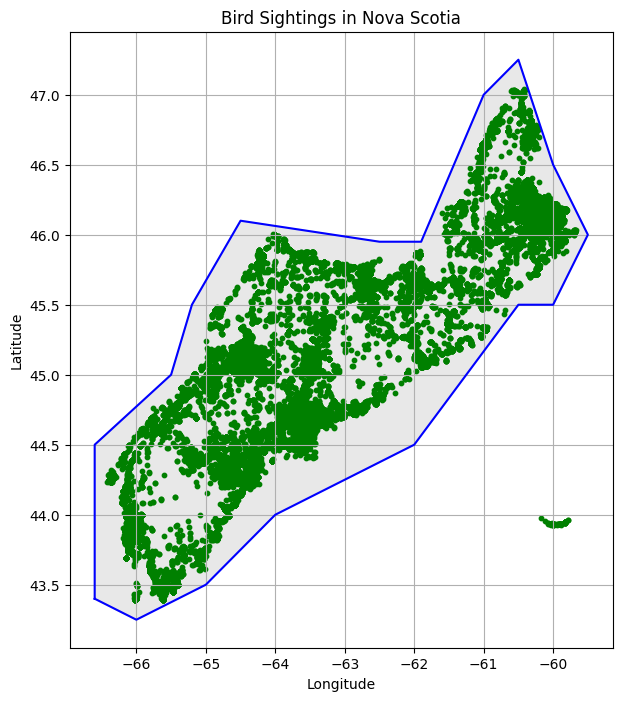

In [11]:
# Lets Visualize it on the Nova Scotia Co-ordinates

fig, ax = plt.subplots(figsize=(7,8))

# plot the map first as the base
ax.plot(lon, lat, color = "blue")
ax.fill(lon, lat, color = "lightgray", alpha = 0.5)

#plot the bird data based on long and lat
ax.scatter(final_data['longitude'], final_data['latitude'], color = "green" , s=10)
ax.grid(True)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Bird Sightings in Nova Scotia")

plt.show()
        

#### Let's use `geopandas` to map sightings on a Nova Scotia map with county boundaries to have a better understanding of it.

In [12]:
geodf = gpd.GeoDataFrame(
    final_data,
    geometry=[Point(xy) for xy in zip(final_data.longitude, final_data.latitude)],
    crs="EPSG:4326"
)

geodf.head()

,date,image_url,latitude,longitude,place_county_name,scientific_name,common_name,taxon_family_name,temp,precip,wind,geometry
0,2020-01-01,https://static.inaturalist.org/photos/58858125...,45.659,-61.913,Antigonish,Spinus tristis,American Goldfinch,Fringillidae,2.7,6.8,32.6,POINT (-61.913 45.659)
1,2020-01-01,https://static.inaturalist.org/photos/58858171...,45.659,-61.913,Antigonish,Zenaida macroura,Mourning Dove,Columbidae,2.7,6.8,32.6,POINT (-61.913 45.659)
2,2020-01-01,https://inaturalist-open-data.s3.amazonaws.com...,45.140,-63.381,Colchester,Mergus merganser,Common Merganser,Anatidae,2.7,6.8,32.6,POINT (-63.381 45.14)
3,2020-01-01,https://inaturalist-open-data.s3.amazonaws.com...,45.138,-63.376,Colchester,Spinus tristis,American Goldfinch,Fringillidae,2.7,6.8,32.6,POINT (-63.376 45.138)
4,2020-01-01,https://inaturalist-open-data.s3.amazonaws.com...,44.710,-63.693,Halifax,Junco hyemalis,Dark-eyed Junco,Passerellidae,2.7,6.8,32.6,POINT (-63.693 44.71)


In [13]:
# Clip Nova Scotia out of canada
ns = gpd.read_file("nova_scotia.geojson") # Data source: data.NovaScotia.ca

ns.head(2)

,:id,:version,:created_at,:updated_at,objectid,featdesc,name,cgndb_key,shape_leng,shape_area,county,fullname,geometry
0,row-fufv_s7y6~3bqw,rv-uzua-bmnz.zsy9,2025-12-05 12:02:18.730000+00:00,2025-12-05 12:02:18.730000+00:00,51,Town,Clark's Harbour,CAHEP,12366.0433254142,2489737.6117166756,Shelburne,Town of Clark's Harbour,"MULTIPOLYGON (((-65.65368 43.45836, -65.65364 ..."
1,row-r7sr.x6jd_xvk4,rv-8msd_nt75-3kzp,2025-12-05 12:02:18.730000+00:00,2025-12-05 12:02:18.730000+00:00,52,Town,Lockeport,CAUZR,17392.278840443323,2123465.385570812,Shelburne,Town of Lockeport,"MULTIPOLYGON (((-65.11838 43.71811, -65.11815 ..."


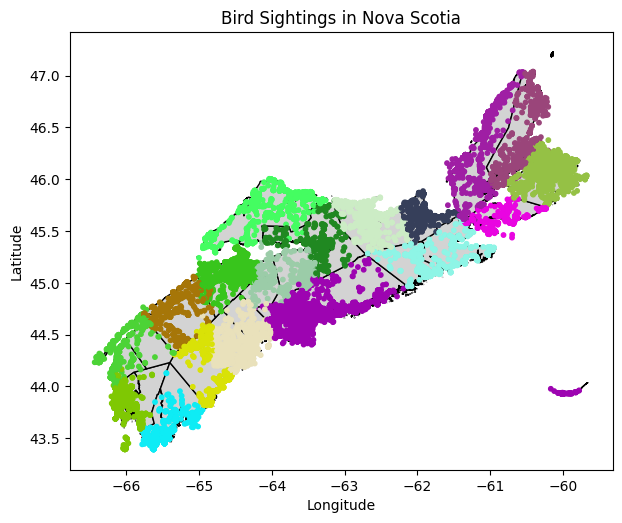

In [14]:
# project the bird data on the map we downloaded

fig, ax = plt.subplots(figsize=(7,8))

# plot the map first as the base
ns.plot(ax=ax, color="lightgray", edgecolor="black")

#plot the bird data based on long and lat
#color coding counties for better visualization
counties = ns['county'].unique()
colors =  {county: tuple(np.random.rand(3,)) for county in counties}

#unique colors to counties but gray if missing data
unique_colors =  [
    colors.get(county, (0.5, 0.5, 0.5))  # gray if county not found
    for county in final_data['place_county_name']
]
    
ax.scatter(final_data['longitude'], final_data['latitude'], color = list(unique_colors) , s=10)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Bird Sightings in Nova Scotia")

plt.show()

# MACHINE LEARNING

### Let's predict what birds( top 5) we are likely to see based on our location: latitude, longitude and month. HALIFAX ONLY.

In [15]:
# making  it easy by just taking the month

final_data['month'] = pd.to_datetime(final_data['date']).dt.month
# Filter bird observations to Halifax County (approximate lat/lon bounds)
halifax_birds = final_data[
    (final_data['latitude'] >= 44.57) & (final_data['latitude'] <= 44.67) &
    (final_data['longitude'] >= -63.63) & (final_data['longitude'] <= -63.50)
].copy()

halifax_birds.shape  # Check how many rows

(8853, 12)

### STEP 6: Feature Engineering and Test-Training data split

In [16]:
# features for model

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

label = LabelEncoder()
final_data['encoded_name'] = label.fit_transform(final_data['common_name'])  

# Month as cyclical features
X = final_data[['latitude', 'longitude', 'month', 'temp', 'precip', 'wind']].copy()
y = final_data['encoded_name']

counts = y.value_counts()
rare_species = counts[counts<=20].index # Keeping bird sightings >=20 for robust statistical analysis aka. threshold.
mask = ~y.isin(rare_species)

X_filtered = X[mask]
y_filtered = y[mask]



X_train, X_test, y_train, y_test = train_test_split(X_filtered, 
                                                    y_filtered, 
                                                    test_size = 0.3, 
                                                    random_state = 42,
                                                    stratify = y_filtered)


### STEP 7: Model training

#### Why RandomForestClassifier?
#### Random Forest is a robust, flexible, and interpretable algorithm that handles the complexities of bird sighting data — sparse sightings, mixed features, and spatial-temporal patterns — making it a safe first choice.

In [17]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=200,         # enough trees to stabilize predictions
    max_depth=10,             # prevent overfitting
    class_weight='balanced',  # handle rare birds
    random_state=42
)

clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### STEP 8: Model evaluation

In [18]:
from sklearn.metrics import accuracy_score, top_k_accuracy_score, f1_score, classification_report

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Overall accuracy: {acc * 100:.2f} %")

top5_acc = top_k_accuracy_score(
    y_true = y_test,
    y_score = clf.predict_proba(X_test),
    k = 5,
    labels = clf.classes_   # only use classes known to the classifier
)

print(f"Top-5 accuracy: {top5_acc * 100:.2f} %")

# Evaluate F1-score
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Macro F1-score (all species equally): {macro_f1 * 100:.2f}")
print(f"Weighted F1-score (weighted by sightings): {weighted_f1 * 100:.2f}")

# Optional: full classification report
print("\nClassification Report for Top 50 Species:")
print(classification_report(y_test, y_pred, target_names=label.classes_))

Overall accuracy: 14.32 %
Top-5 accuracy: 40.92 %
Macro F1-score (all species equally): 12.73
Weighted F1-score (weighted by sightings): 11.68

Classification Report for Top 50 Species:
                           precision    recall  f1-score   support

      American Black Duck       0.41      0.02      0.03       987
            American Crow       0.15      0.02      0.03       950
       American Goldfinch       0.30      0.06      0.10       731
    American Herring Gull       0.67      0.04      0.08      1695
           American Robin       0.13      0.05      0.07       740
          American Wigeon       0.24      0.22      0.23       388
               Bald Eagle       0.17      0.03      0.04       788
   Black-capped Chickadee       0.25      0.11      0.15       989
                 Blue Jay       0.14      0.07      0.09       724
               Bufflehead       0.10      0.37      0.16       282
             Canada Goose       0.32      0.05      0.09       709
         

### STEP 9: Model prediction

In [19]:
import numpy as np
# Halifax Only
new_data = pd.DataFrame({'latitude':[44.64], 'longitude':[-63.57], 'month':[6], 'temp':[30.1], 'precip':[9.6], 'wind':[10.5] })

# Predict probabilities
probs = clf.predict_proba(new_data)[0]

# Top 5 species
top5_idx = np.argsort(probs)[-5:][::-1]
top5_species = label.inverse_transform(top5_idx)
top5_probs = probs[top5_idx]

for species, prob in zip(top5_species, top5_probs):
    print(f"{species}: {prob * 100:.2f} %")

European Starling: 8.71 %
Feral Pigeon: 6.77 %
Northern Yellow Warbler: 6.51 %
Osprey: 5.54 %
Mallard: 4.37 %


# GENERATIVE AI

#### For GenAI application, I have used a small OpenAI application where it tells a bit about the bird user searches based on name and city. For now, we will only enter Halifax as we have data limited to it.

In [22]:
from openai import OpenAI

# Initialize OpenAI client
client = OpenAI(api_key="YOUR-API-KEY")
# --- Prepare dataset ---
# final_data should have: ['common_name', 'date', 'location', 'image_url']
final_data['date'] = pd.to_datetime(final_data['date'])

# --- User input ---
bird_name = input("Enter the bird name: ").strip().lower()
user_location = input("Enter your location (e.g., city or region): ").strip().lower()

# --- Filter dataset for bird near location ---
bird_data = final_data[
    (final_data['common_name'].str.lower() == bird_name) &
    (final_data['place_county_name'].str.lower().str.contains(user_location))
]

if bird_data.empty:
    last_seen_info = f"No recent sightings of {bird_name} near {user_location} found in the dataset."
else:
    recent_sighting = final_data.sort_values('date', ascending=False).iloc[0]
    last_seen_date = recent_sighting['date'].strftime('%Y-%m-%d')
    last_seen_location = recent_sighting['place_county_name']
    last_seen_info = f"The bird {bird_name} was last seen near {last_seen_location} on {last_seen_date}."

# --- Prepare prompt for OpenAI ---
prompt = f"""
Tell me about the bird '{bird_name}':
- Is it endangered?
- Its conservation status
- Tips to improve biodiversity for this species

Additionally, based on my dataset, here is info about recent sightings:
{last_seen_info}

Keep the answer concise and informative.
"""

# --- Call OpenAI ---
response = client.responses.create(
    model="gpt-4.1-mini",
    input=[{"role": "user", "content": prompt}]
)

# --- Output ---
print("\nBird Insights:\n")
print(response.output_text)

Enter the bird name:  Northern Cardinal
Enter your location (e.g., city or region):  Halifax



Bird Insights:

The northern cardinal (Cardinalis cardinalis) is not endangered. Its conservation status is currently classified as Least Concern by the IUCN.

Tips to improve biodiversity for the northern cardinal:
- Plant native shrubs and trees that provide berries and shelter.
- Provide bird feeders with sunflower seeds, a favorite food of cardinals.
- Maintain a mix of open areas and dense cover for nesting and foraging.
- Avoid pesticides to protect their insect food sources.

Your dataset shows the northern cardinal was last seen near Kings on 2026-03-19, indicating its continued presence in that area.
